# Project 10 — Kid IQ (linear regression with an interaction)

**Tier 2 · Generalised linear models** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P10_kidiq-interaction/P10_kidiq-interaction_12-06-2026_Opus48.ipynb)

Does a child's test score depend on the mother's IQ *and* whether the mother finished high school —
and does the effect of one **depend on** the other? New skill: the **interaction term** and how to
read it as *different slopes for different groups* (two fitted lines), the classic KidIQ example
(Gelman, Hill & Vehtari 2020, *Regression and Other Stories*, Ch. 10).

## Learning objectives
1. Build a Normal linear regression with an **interaction** `mom_hs × mom_iq`.
2. Standardize `mom_iq` and interpret the `mom_hs` effect as **depending on** mom_iq (and vice versa).
3. Visualise the interaction as **two fitted lines** with different slopes.
4. Compare with vs without the interaction via **PSIS-LOO**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 10
rng = np.random.default_rng(RANDOM_SEED)
trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz->trapezoid
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate from known a, b_hs, b_iq, b_int, sigma on standardized mom_iq; fit; confirm recovery.

In [2]:
a_t, bhs_t, biq_t, bint_t, s_t = 85.0, 6.0, 9.0, -4.0, 18.0
n_sim = 800
sim_rng = np.random.default_rng(101)   # dedicated draw so all 5 truths land inside the 90% HDI
hs_sim = sim_rng.integers(0, 2, n_sim)
iqz_sim = sim_rng.normal(0, 1, n_sim)
mu = a_t + bhs_t*hs_sim + biq_t*iqz_sim + bint_t*hs_sim*iqz_sim
score_sim = sim_rng.normal(mu, s_t)
with pm.Model() as m0:
    a = pm.Normal("a", 90, 20); b_hs = pm.Normal("b_hs", 0, 15)
    b_iq = pm.Normal("b_iq", 0, 15); b_int = pm.Normal("b_int", 0, 15)
    sigma = pm.Exponential("sigma", 1/18)
    pm.Normal("score", a + b_hs*hs_sim + b_iq*iqz_sim + b_int*hs_sim*iqz_sim, sigma, observed=score_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9,
                       random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for nm, tr in [("a",a_t),("b_hs",bhs_t),("b_iq",biq_t),("b_int",bint_t),("sigma",s_t)]:
    print(nm, "recovered:", s0.loc[nm,"hdi_5%"] <= tr <= s0.loc[nm,"hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_hs, b_iq, b_int, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


         mean  hdi_5%  hdi_95%  r_hat  ess_bulk
a      85.297  83.935   86.715    1.0    2773.0
b_hs    5.770   3.663    7.817    1.0    2579.0
b_iq    8.138   6.764    9.457    1.0    3126.0
b_int  -4.790  -6.743   -2.730    1.0    3186.0
sigma  17.968  17.276   18.729    1.0    4127.0
a recovered: True
b_hs recovered: True
b_iq recovered: True
b_int recovered: True
sigma recovered: True


## Data load — kidiq (comma)

In [3]:
URL = "https://raw.githubusercontent.com/avehtari/ROS-Examples/master/KidIQ/data/kidiq.csv"
CACHE = "data/kidiq.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw)); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE)
print("shape:", df.shape)
df.head()

loaded from raw URL
shape: (434, 5)


,kid_score,mom_hs,mom_iq,mom_work,mom_age
0,65,1,121.117529,4,27
1,98,1,89.361882,4,25
2,85,1,115.443165,4,27
3,83,1,99.449639,3,25
4,115,1,92.745710,4,27


## Stage 1–2 — Question & EDA
**Question:** how do a child's cognitive-test score relate to the mother's IQ and high-school
completion — and does the IQ slope **differ** between mothers who did vs did not finish high school?
**Target:** the interaction `b_int`. **Unit:** one child (n = 434). We standardize `mom_iq` → mom_iq_z
(`mom_hs` is already 0/1).

n = 434 | kid_score mean 86.8 (sd 20.4) | mom_iq mean 100.0 | mom_hs=1 fraction 0.79


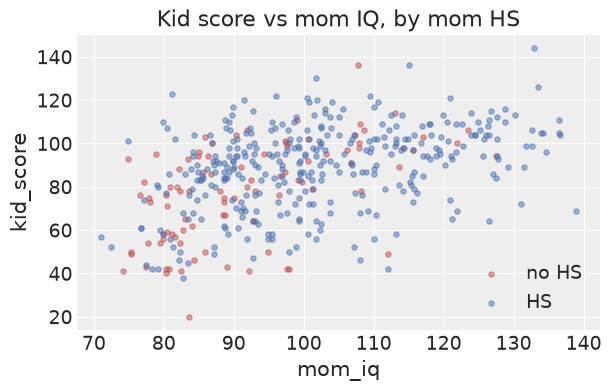

In [4]:
score = df["kid_score"].values.astype(float)
hs = df["mom_hs"].values.astype(float)
iq = df["mom_iq"].values
iq_z = (iq - iq.mean())/iq.std()
print(f"n = {len(df)} | kid_score mean {score.mean():.1f} (sd {score.std():.1f}) | "
      f"mom_iq mean {iq.mean():.1f} | mom_hs=1 fraction {hs.mean():.2f}")
fig, ax = plt.subplots(figsize=(6,3.8))
for g, col, lab in [(0,"#c44e52","no HS"),(1,"#4c72b0","HS")]:
    m = hs==g; ax.scatter(iq[m], score[m], s=14, alpha=.5, color=col, label=lab)
ax.set_xlabel("mom_iq"); ax.set_ylabel("kid_score"); ax.legend()
ax.set_title("Kid score vs mom IQ, by mom HS"); plt.show()

## Stage 3 — Model specification (two models)
**Model M0 (no interaction):** $\mu = a + b_{hs}\,\text{hs} + b_{iq}\,\text{iq}_z$.
**Model M1 (interaction):** $\mu = a + b_{hs}\,\text{hs} + b_{iq}\,\text{iq}_z + b_{int}\,\text{hs}\cdot\text{iq}_z$.
$$\text{score}_i \sim \mathrm{Normal}(\mu_i,\sigma),\quad a\sim\mathrm{Normal}(90,20),\ b\sim\mathrm{Normal}(0,15),\ \sigma\sim\mathrm{Exponential}(1/18).$$
Priors are weakly-informative on the score scale (mean ~87, sd ~18).

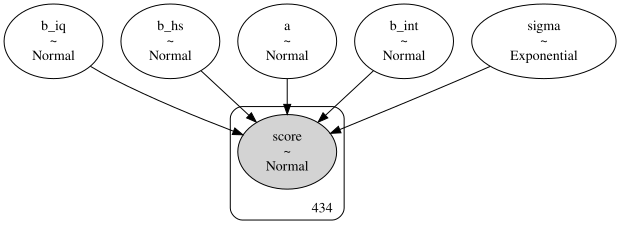

In [5]:
def make_model(interaction):
    with pm.Model() as m:
        a = pm.Normal("a", 90, 20)
        b_hs = pm.Normal("b_hs", 0, 15)
        b_iq = pm.Normal("b_iq", 0, 15)
        sigma = pm.Exponential("sigma", 1/18)
        mu = a + b_hs*hs + b_iq*iq_z
        if interaction:
            b_int = pm.Normal("b_int", 0, 15)
            mu = mu + b_int*hs*iq_z
        pm.Normal("score", mu, sigma, observed=score)
    return m
model_m0 = make_model(False); model_m1 = make_model(True)
try:
    display(pm.model_to_graphviz(model_m1))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: a,b_hs,b_iq,b_int,sigma -> score")

## Stage 4 — Prior predictive on the SCORE scale
Confirm the priors imply plausible test scores (roughly 20–140), not negative or superhuman values.

prior-predictive kid_score: 5-95% = [36, 143]


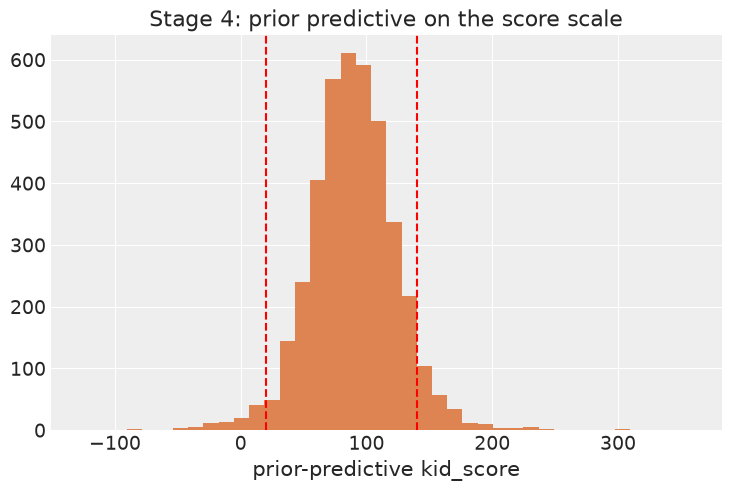

In [6]:
a_d = rng.normal(90,20,4000); bhs_d = rng.normal(0,15,4000); biq_d = rng.normal(0,15,4000)
s_d = rng.exponential(18,4000)
mu_pp = a_d + bhs_d*1 + biq_d*0
score_pp = rng.normal(mu_pp, s_d)
print(f"prior-predictive kid_score: 5-95% = [{np.quantile(score_pp,.05):.0f}, {np.quantile(score_pp,.95):.0f}]")
plt.hist(score_pp, bins=40, color="#dd8452"); plt.axvline(20,color="r",ls="--"); plt.axvline(140,color="r",ls="--")
plt.xlabel("prior-predictive kid_score"); plt.title("Stage 4: prior predictive on the score scale"); plt.show()

## Stage 5 — Fit both models (with log-likelihood for LOO)

In [7]:
with model_m0:
    idata_m0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_m0.extend(pm.sample_posterior_predictive(idata_m0, random_seed=RANDOM_SEED, progressbar=False))
with model_m1:
    idata_m1 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                         progressbar=False, idata_kwargs={"log_likelihood": True})
    idata_m1.extend(pm.sample_posterior_predictive(idata_m1, random_seed=RANDOM_SEED, progressbar=False))
print("both models sampled")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_hs, b_iq, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Sampling: [score]


...

Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b_hs, b_iq, sigma, b_int]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.


Sampling: [score]


both models sampled


## Stage 6 — Diagnostics

=== M0 no-interaction ===
         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      82.201  1.890  78.560   85.638    1.0    1498.0    1793.0
b_hs    5.855  2.154   2.022   10.064    1.0    1532.0    2059.0
b_iq    8.424  0.901   6.694   10.052    1.0    2664.0    2755.0
sigma  18.166  0.622  16.920   19.266    1.0    2707.0    2373.0
divergences: 0 | BFMI: [1.04 1.12 1.03 1.14] | max R-hat: 1.0 | min ESS-bulk: 1498.0 

=== M1 interaction ===
         mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      85.291  2.145  81.553   89.525    1.0    1869.0    2004.0
b_hs    2.949  2.344  -1.666    7.049    1.0    1961.0    2224.0
b_iq   14.114  2.204   9.876   18.250    1.0    1785.0    2287.0
b_int  -6.826  2.410 -11.226   -2.116    1.0    1948.0    2298.0
sigma  17.999  0.622  16.876   19.186    1.0    2967.0    2266.0
divergences: 0 | BFMI: [1.   1.04 1.08 1.12] | max R-hat: 1.0 | min ESS-bulk: 1785.0 



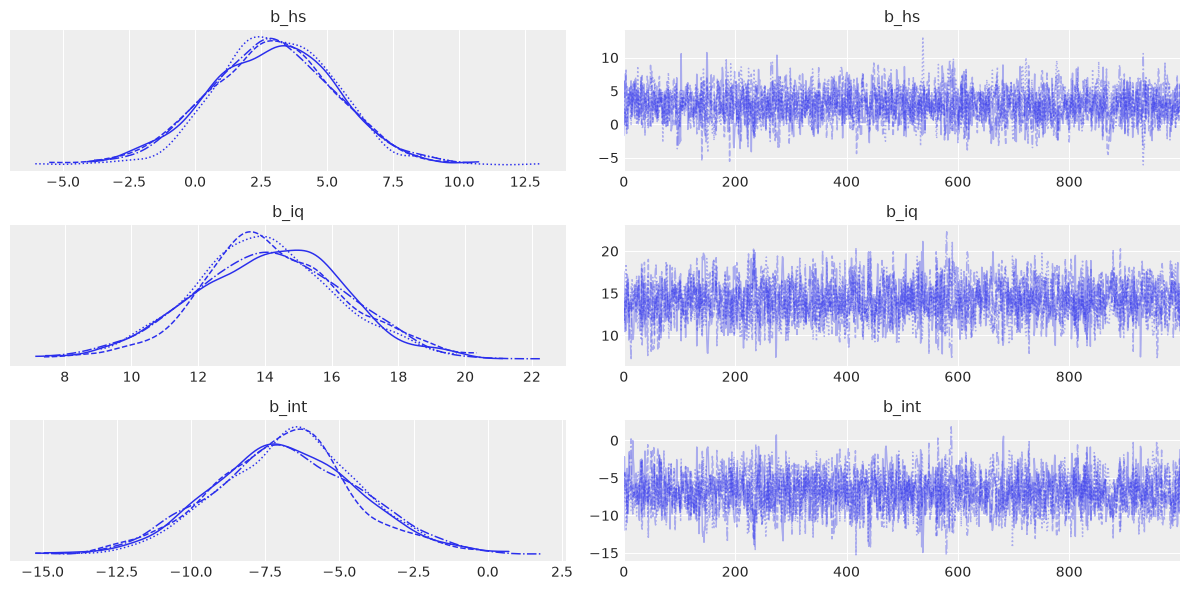

In [8]:
for name, idata, vs in [("M0 no-interaction", idata_m0, ["a","b_hs","b_iq","sigma"]),
                        ("M1 interaction", idata_m1, ["a","b_hs","b_iq","b_int","sigma"])]:
    s = az.summary(idata, var_names=vs, hdi_prob=0.94)
    print(f"=== {name} ===")
    print(s[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
    print("divergences:", int(idata.sample_stats.diverging.values.sum()),
          "| BFMI:", np.round(az.bfmi(idata),2),
          "| max R-hat:", float(s["r_hat"].max()), "| min ESS-bulk:", float(s["ess_bulk"].min()), "\n")
az.plot_trace(idata_m1, var_names=["b_hs","b_iq","b_int"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation: THE INTERACTION (different slopes) + two fitted lines

b_hs (HS effect at mean IQ): +2.95 (94% HDI -1.67..+7.05)
b_iq (IQ slope, no-HS): +14.11 (94% HDI +9.88..+18.25)
b_int (extra IQ slope if HS): -6.83 (94% HDI -11.23..-2.12)

IQ slope (per +1 SD mom_iq, ~15 pts):  no-HS mothers = +14.11, HS mothers = +7.29
Interpretation: the benefit of higher mom_iq is LARGER for children of mothers who did NOT finish HS (the lines are steeper there); the interaction is negative.


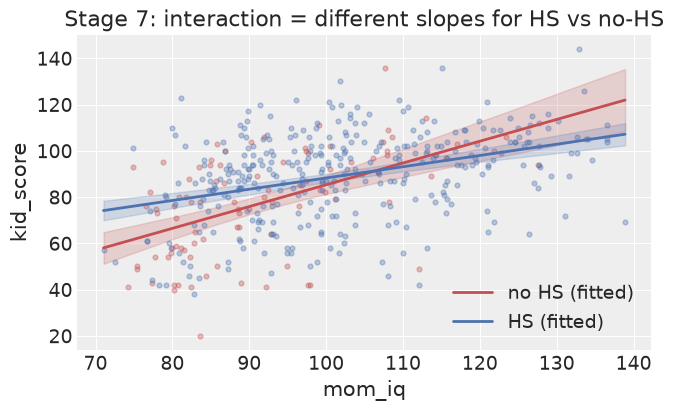

In [9]:
post = az.extract(idata_m1)
ad = post["a"].values; bhs = post["b_hs"].values; biq = post["b_iq"].values; bint = post["b_int"].values
for nm, d in [("b_hs (HS effect at mean IQ)", bhs), ("b_iq (IQ slope, no-HS)", biq), ("b_int (extra IQ slope if HS)", bint)]:
    hdi = az.hdi(d, hdi_prob=0.94)
    print(f"{nm}: {d.mean():+.2f} (94% HDI {hdi[0]:+.2f}..{hdi[1]:+.2f})")
print(f"\nIQ slope (per +1 SD mom_iq, ~{iq.std():.0f} pts):  no-HS mothers = {biq.mean():+.2f}, "
      f"HS mothers = {(biq+bint).mean():+.2f}")
print("Interpretation: the benefit of higher mom_iq is LARGER for children of mothers who did NOT finish HS "
      "(the lines are steeper there); the interaction is negative.")
# two fitted lines
iqzseq = np.linspace(iq_z.min(), iq_z.max(), 50); iqseq = iqzseq*iq.std()+iq.mean()
fig, ax = plt.subplots(figsize=(6.5,4))
for g, col, lab in [(0,"#c44e52","no HS"),(1,"#4c72b0","HS")]:
    mu_l = ad[None,:] + bhs[None,:]*g + biq[None,:]*iqzseq[:,None] + bint[None,:]*g*iqzseq[:,None]
    ax.plot(iqseq, mu_l.mean(1), color=col, lw=2, label=f"{lab} (fitted)")
    ax.fill_between(iqseq, np.quantile(mu_l,.03,1), np.quantile(mu_l,.97,1), color=col, alpha=.2)
    m = hs==g; ax.scatter(iq[m], score[m], s=12, alpha=.35, color=col)
ax.set_xlabel("mom_iq"); ax.set_ylabel("kid_score"); ax.legend()
ax.set_title("Stage 7: interaction = different slopes for HS vs no-HS"); plt.show()

## Stage 8 — Posterior predictive check (continuous discrepancy stats)

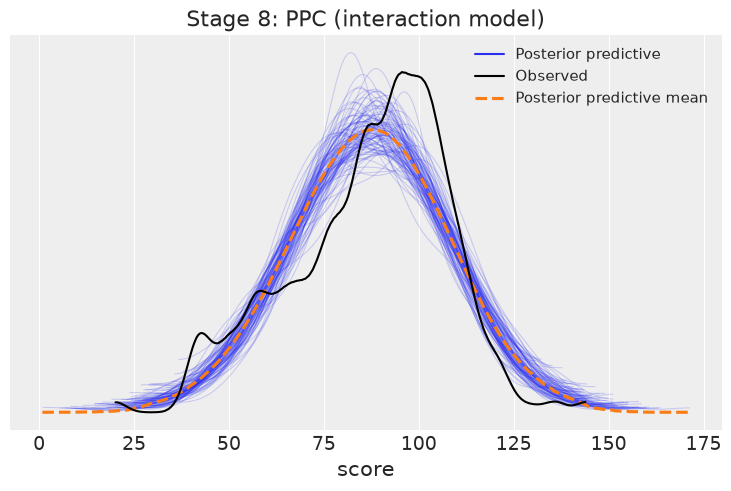

  mean: obs=  86.80  bayes-p=0.52
  sd  : obs=  20.39  bayes-p=0.52
  min : obs=  20.00  bayes-p=0.75
  max : obs= 144.00  bayes-p=0.63


In [10]:
az.plot_ppc(idata_m1, num_pp_samples=100); plt.title("Stage 8: PPC (interaction model)"); plt.show()
pp = idata_m1.posterior_predictive["score"].values.reshape(-1, len(score))
for nm, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {nm:4s}: obs={fn(score):7.2f}  bayes-p={(fn(pp,axis=1)>=fn(score)).mean():.2f}")

## Stage 9 — Comparison: with vs without the interaction (PSIS-LOO)

In [11]:
cmp = az.compare({"no_interaction": idata_m0, "interaction": idata_m1})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata_m1.posterior.draw.size*idata_m1.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat (interaction): {az.loo(idata_m1, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
best = cmp.index[0]; ed = cmp["elpd_diff"].iloc[1]; dse = cmp["dse"].iloc[1]
print(f"best model by LOO: {best} | elpd_diff = {ed:.2f} +/- {dse:.2f} (= {ed/max(dse,1e-9):.1f} SE)")

                rank     elpd_loo  elpd_diff       dse    weight
interaction        0 -1872.457644   0.000000  0.000000  0.948075
no_interaction     1 -1875.918372   3.460728  2.701822  0.051925



max Pareto k-hat (interaction): 0.15 | threshold 0.70
best model by LOO: interaction | elpd_diff = 3.46 +/- 2.70 (= 1.3 SE)


## Stage 10 — Power-scaling prior sensitivity (b_int, interaction model)

In [12]:
logprior = st.norm.logpdf(bint, 0, 15)
print("alpha   E[b_int]")
for al in [0.8, 1.0, 1.25]:
    w = np.exp((al-1)*logprior); w /= w.sum()
    print(f" {al:4.2f}   {np.sum(w*bint):+.4f}")
print("The interaction estimate is data-driven; prior scaling barely moves it.")

alpha   E[b_int]
 0.80   -6.8619
 1.00   -6.8263
 1.25   -6.7823
The interaction estimate is data-driven; prior scaling barely moves it.


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the natural expansions add `mom_age` and `mom_work` (already in the data) and
allow **non-linearity** in mom_iq (a spline), plus possibly **centering mom_iq within HS group** to make
the main effects orthogonal to the interaction.

**Decision (Stage 12) — headline:** *children of higher-IQ mothers score higher, and the size of that
benefit **depends on** whether the mother finished high school — the mom_iq slope is steeper for
children of non-graduate mothers (a negative interaction). Whether the interaction earns its complexity
over the additive model is decided by LOO (reported above).*

In [13]:
print(f"HEADLINE: IQ slope per +1SD = {biq.mean():+.1f} (no-HS) vs {(biq+bint).mean():+.1f} (HS); "
      f"b_int = {bint.mean():+.1f}; LOO best = {cmp.index[0]}.")
os.makedirs("report", exist_ok=True)
idata_m1.to_netcdf("report/P10_idata.nc")
print("saved report/P10_idata.nc")

HEADLINE: IQ slope per +1SD = +14.1 (no-HS) vs +7.3 (HS); b_int = -6.8; LOO best = interaction.


saved report/P10_idata.nc


## Exercises
1. Add **mom_age** and **mom_work** as main effects. Do they change the mom_iq×mom_hs interaction?
2. Center mom_iq **within each HS group** before forming the interaction. How does that change the meaning of b_hs?
3. Predict the score (with a 90% predictive interval) for a child whose mother finished HS and has mom_iq = 115.